## 1. Импорты

In [1]:
import os
import gc
import sys
import json
import toml
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import matplotlib.pyplot as plt
import tqdm
from prefect.blocks.system import Secret
from prefect.variables import Variable
import plotly.io as pio
from scipy.stats import linregress

import lightgbm as lgb
from sklearn.metrics import roc_auc_score

pio.renderers.default = "plotly_mimetype"

In [2]:
!pip install hyperopt

Looking in indexes: https://nexus/repository/pypi-proxy/simple


In [3]:
import lightgbm as lgb
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_squared_error, mean_absolute_error
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

## 2. Параметры

In [4]:
secret_cdw = await Secret.load("pass-sb-analytics")
secret_space = await Secret.load("pass-space")
secret_sb_dirkaim = await Secret.load("pass-sb-dirkaim")

In [5]:
SUBTASK = 'v1'             # Подзадача (или версия, свободное наименование)
COMMENT = ""               # Текст-подсказка в свободной форме, пояснение для разработчика
SEED = 41                  # random_state

USERNAME_SPACE = "analytics"
USERNAME_CDW = "sb_analytics"
USERNAME_SB_DIRKAIM = "kovalenkovdy"
PASSWORD_SPACE = secret_space.get()
PASSWORD_CDW = secret_cdw.get()
PASSWORD_SB_DIRKAIM = secret_sb_dirkaim.get()


common_params = toml.load('common_params.toml')

AUTHOR = common_params['AUTHOR']        # Разработчик
PREFIX = common_params['PREFIX']        # Префикс
TASK_NUM = common_params['TASK_NUM']    # Номер задачи eservices
OUT_TABLE = common_params['OUT_TABLE']  # out_table
ML_TYPE = common_params['ML_TYPE']      # Тип ML-задачи: reg - регрессия, clf - классификация clf, mclf - мультирег,mclf - мультикласс
TARGET = common_params['TARGET']        # Имя целевой переменной
TIME_COL = common_params['TIME_COL']    # Имя колонки с датами

PRIMARY_KEY = ['client_did', TIME_COL]      # Объект предсказания, ключ

# Технические поля - не фичи, не id, не дата, для удаления
TECH_COLS = [
    'ub_clients_registration_dt_diff_report_date',
    'ub_clients_client_email',
    'ub_clients_mailing_consent',
    "card_report_date_diff_card_work_dt_aggmin", # ЛИК в фиче! 18.12.2025
    'transaction_total_trans_cnt_1m',
    'transaction_ratio_cnt_trans_1m_to_1m',
    'transaction_supermarkets_trans_cnt_12m'
]


# Пути (для чтения файлов)
PATH_TO_UTILS = common_params['PATH_TO_UTILS'] # Путь к кастомной библиотеке toolbox

# Пути (для сохранения файлов)
DATA_FOLDER = common_params['DATA_FOLDER']            # Папка с выборками
MODELS_FOLDER = common_params['MODELS_FOLDER']        # Файлы модели
FEATURES_FOLDER = common_params['FEATURES_FOLDER']    # Папка с фичами
REPORTS_FOLDER = f'{MODELS_FOLDER}/{SUBTASK}/report'  # Папка с отчетами

# Пути к файлам
PATH_TO_SAMPLE = f'./{DATA_FOLDER}/sample.parquet'    # Исходная выборка для разработки
PATH_MODELS_DATA = f"./{MODELS_FOLDER}/{SUBTASK}"     # Папка с файлми модели

In [6]:
print(PATH_TO_SAMPLE, FEATURES_FOLDER, MODELS_FOLDER)
print(PATH_MODELS_DATA)
print(REPORTS_FOLDER)

./data/sample.parquet features_data models_data
./models_data/v1
models_data/v1/report


In [7]:
# Создаем необходимые директории
os.makedirs(MODELS_FOLDER, exist_ok=True)
os.makedirs(PATH_MODELS_DATA, exist_ok=True)
os.makedirs(REPORTS_FOLDER, exist_ok=True)

### Загрузка кастомного модуля

In [8]:
sys.path.append(PATH_TO_UTILS)

In [9]:
!pip install openpyxl # для from toolbox.modeling_utils.report

Looking in indexes: https://nexus/repository/pypi-proxy/simple


In [9]:
from toolbox.modeling_utils import preprocessing 
from toolbox.modeling_utils import report
from toolbox.modeling_utils import feature_selection
from toolbox.modeling_utils import report_generator
from toolbox import oracle

## 3. Логгирование

In [10]:
# Логгирование
import logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)s %(message)s",
    datefmt = "%Y-%m-%d %H:%M",
    handlers = [
        # logging.FileHandler("logfile.log"),
        logging.StreamHandler(),
    ])

In [13]:
!pip install clearml

Looking in indexes: https://nexus/repository/pypi-proxy/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 63.4 MB/s eta 0:00:00


In [11]:
os.environ["CLEARML_AUTO_LOG_ARTIFACTS"] = "0" 
os.environ["CLEARML_MONITOR_SYSTEM"]    = "0"
os.environ["CLEARML_AUTO_CONNECT_FRAMEWORKS"] = "0"

import clearml
from clearml import Task, Logger, Model

PROJECT_NAME = f"eservices-{TASK_NUM}"

clearml_task = Task.init(
    project_name=PROJECT_NAME,
    task_name=f"{PROJECT_NAME}_{SUBTASK}",
    auto_connect_streams=False,
    reuse_last_task_id=False
)

ClearML Task: created new task id=982260653c1f4450ab0be5b5eec1e02e
ClearML results page: https://clearml-retail.run.fc.uralsibbank.ru/projects/12abac3b5607421e96058d1207fbf5cb/experiments/982260653c1f4450ab0be5b5eec1e02e/output/log
2026-05-20 18:39:25,272 - clearml.Task - INFO - Storing jupyter notebook directly as code
2026-05-20 18:39:25,272 - clearml.Task - INFO - Storing jupyter notebook directly as code
2026-05-20 18:39:25,504 - clearml.resource_monitor - WARNING - Could not fetch GPU stats: NVML Shared Library Not Found
ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring
2026-05-20 18:39:29,501 - clearml.storage - INFO - Uploading: 6.19MB from /home/jovyan/Clip/template/02_template_regression.ipynb


                                            0% | 0.00/6.19 MB [00:00<?, ?MB/s]: 

2026-05-20 18:39:29,575 - clearml.storage - INFO - Uploading: 6.19MB from /home/jovyan/Clip/template/02_template_regression.ipynb



█████████████████████████████████ 100% | 6.19/6.19 MB [00:00<00:00, 36.84MB/s]: 


2026-05-20 18:39:29,905 - clearml.storage - INFO - Uploading: 6.19MB from /home/jovyan/Clip/template/02_template_regression.ipynb


█████████████████████████████████ 100% | 6.19/6.19 MB [00:00<00:00, 18.29MB/s]: 

2026-05-20 18:39:29,916 - clearml.storage - ERROR - Exception encountered while uploading Failed uploading object /eservices-20158/eservices-20158_v1.982260653c1f4450ab0be5b5eec1e02e/artifacts/notebook/02_template_regression.ipynb to https://clearml-retail.run.fc.uralsibbank.ru (413): <html>
<head><title>413 Request Entity Too Large</title></head>
<body>
<center><h1>413 Request Entity Too Large</h1></center>
<hr><center>nginx</center>
</body>
</html>



ClearML Monitor: Could not detect iteration reporting, falling back to iterations as seconds-from-start
2026-05-20 18:49:17,461 - clearml.Metrics - ERROR - Action failed <413/0: events.add_batch (<html>
<head><title>413 Request Entity Too Large</title></head>
<body>
<center><h1>413 Request Entity Too Large</h1></center>
<hr><center>nginx</center>
</body>
</html>
)>
2026-05-20 19:22:32,214 - clearml.Metrics - ERROR - Action failed <413/0: events.add_batch (<html>
<head><title>413 Request Entity Too Large</title></head>
<body>
<center><h1>413 Request Entity Too Large</h1></center>
<hr><center>nginx</center>
</body>
</html>
)>


## 4 Чтение данных

In [12]:
# Пути к фичам
filenames = list(filter(lambda file: file.startswith(PREFIX.lower()) & file.endswith('.parquet'),  
                        os.listdir(FEATURES_FOLDER)))
feature_paths = [f"{FEATURES_FOLDER}/{filename}" for filename in filenames]

In [13]:
# Выборка для разработки
sample = pd.read_parquet(PATH_TO_SAMPLE)
display(sample.shape)
display(sample.head(3))

# Фичи
df_features_lst = list()
for path in tqdm.tqdm(feature_paths):
    df_features_lst.append(pd.read_parquet(path))

█████████████████████████████████ 100% | 6.19/6.19 MB [00:39<00:00,  6.42s/MB]: 


(270200, 5)

,client_did,report_date,current_debt_amt,new_limit,target
0,20127190033,2024-05-23,0.00,800000,0E-46
1,20117845254,2023-12-21,7955.77,90000,0.0883974444444444444444444444444444444444000000
2,1171690331,2024-04-25,9254.71,180000,0.0514150555555555555555555555555555555556000000


100%|██████████| 28/28 [00:05<00:00,  5.39it/s]


## 4. EDA

In [14]:
# Динамика таргета во времени
sample['year_month'] = sample[TIME_COL].dt.strftime('%Y-%m-01')
sample['year_month'] = pd.to_datetime(sample['year_month'])

In [15]:
import plotly.express as px
import plotly.graph_objects as go

year_month,2023-11-01,2023-12-01,2024-01-01,2024-02-01,2024-03-01,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01
client_did,4230,22065,4210,4396,11331,9780,5474,22940,13431,10555,18529,11191


year_month,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01
client_did,10650,6434,12970,9212,16086,6391,8752,18696,10112,10595,9082,13088


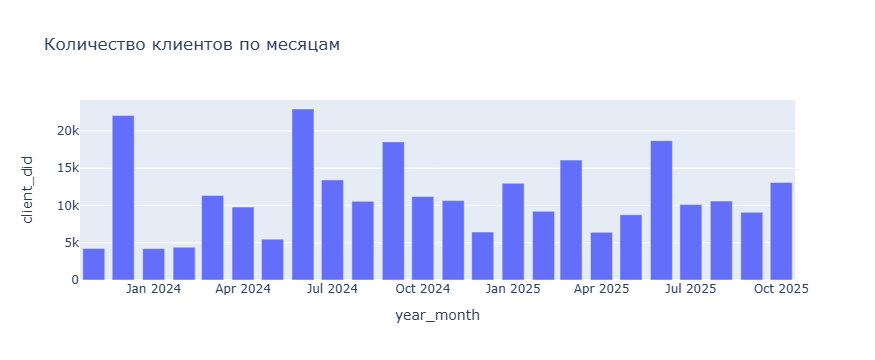

In [16]:
display(sample[sample['year_month'] < '2024-11-01'].pivot_table(values=['client_did'],
                index=['year_month'],
                aggfunc='count',
                margins=False).T)
display(sample[sample['year_month'] >= '2024-11-01'].pivot_table(values=['client_did'],
                index=['year_month'],
                aggfunc='count',
                margins=False).T)

pt = (sample
    .pivot_table(
        values=["client_did"],
        index=["year_month"],
        aggfunc="count",
        margins=False,).reset_index())

fig_sample = px.bar(
    pt,
    x="year_month",
    y="client_did",
    orientation="v",
    title="Количество клиентов по месяцам",
)

fig_sample.show()  # в ноутбуке — опционально

In [17]:
Logger.current_logger().report_plotly(
    title="Кол-во клиентов в выборке по месяцам",
    series="",
    figure=fig_sample)

#### Если есть сильный перекос по месяцам - отберем одинаковое количество из каждого месяца - по 10 000

In [ ]:
# sample_new = sample.groupby('report_date', group_keys=False).apply(lambda g: g.sample(n=min(10000, len(g)), random_state=42)).reset_index(drop=True)

In [ ]:
display(sample_new.pivot_table(values=['client_did'],
                index=['report_date'],
                aggfunc='count',
                margins=False).T)
sample_new.pivot_table(values=['client_did'],
                index=['report_date'],
                aggfunc='count',
                margins=False).plot(kind='barh', stacked=True, legend=True, rot=0,
                                    title='Количество клиентов по месяцам'
                                );

### Таргет по месяцам (аналог уровня таргета в классификации)
Среднее и медиана целевой переменной по месяцам — видно тренд и сезонность.

In [18]:
def target_by_month(df, date_col, target_cols, agg="mean", figsize=(12, 4), show=True):
    """График агрегата таргета по месяцам (agg: 'mean' или 'median')."""
    if isinstance(target_cols, str):
        target_cols = [target_cols]

    df = df.copy()
    df["_month"] = df[date_col].dt.to_period("M")
    g = df.groupby("_month", observed=True)[target_cols].agg(agg)

    plot_df = g.reset_index()
    plot_df["_month"] = plot_df["_month"].astype(str)

    fig = px.line(
        plot_df,
        x="_month",
        y=target_cols,
        title=f"Таргет по месяцам ({agg})",
        markers=True,
    )

    fig.update_layout(
        width=int(figsize[0] * 80),
        height=int(figsize[1] * 80),
        yaxis_title=agg,
        legend=dict(
            yanchor="top",
            y=1,
            xanchor="left",
            x=1.02,
        ),
        margin=dict(r=120),
    )
    fig.update_xaxes(tickangle=45)

    if show:
        fig.show()

    return g, fig

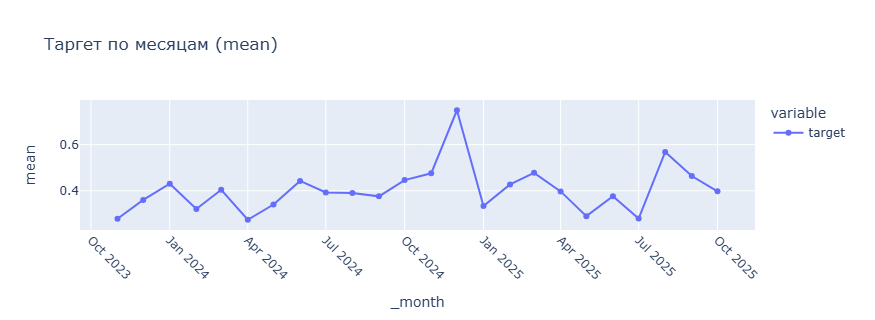

In [19]:
g, fig = target_by_month(sample, "report_date", TARGET, agg="mean")

In [20]:
Logger.current_logger().report_plotly(
    title="Таргет по месяцам",
    series="",
    figure=fig,
)

2026-05-20 18:41:18,384 - clearml.storage - INFO - Uploading: 6.13MB from /home/jovyan/Clip/template/02_template_regression.ipynb


                                            0% | 0.00/6.13 MB [00:00<?, ?MB/s]: 

2026-05-20 18:41:18,451 - clearml.storage - INFO - Uploading: 6.13MB from /home/jovyan/Clip/template/02_template_regression.ipynb



█████████████████████████████████ 100% | 6.13/6.13 MB [00:00<00:00, 82.34MB/s]: 

2026-05-20 18:41:18,522 - clearml.storage - INFO - Uploading: 6.13MB from /home/jovyan/Clip/template/02_template_regression.ipynb



█████████████████████████████████ 100% | 6.13/6.13 MB [00:00<00:00, 77.49MB/s]: 

2026-05-20 18:41:18,533 - clearml.storage - ERROR - Exception encountered while uploading Failed uploading object /eservices-20158/eservices-20158_v1.982260653c1f4450ab0be5b5eec1e02e/artifacts/notebook/02_template_regression.ipynb to https://clearml-retail.run.fc.uralsibbank.ru (413): <html>
<head><title>413 Request Entity Too Large</title></head>
<body>
<center><h1>413 Request Entity Too Large</h1></center>
<hr><center>nginx</center>
</body>
</html>



### Распределение таргета
Гистограмма и ящик с усами — асимметрия, выбросы, нули.

In [21]:
from plotly.subplots import make_subplots

█████████████████████████████████ 100% | 6.13/6.13 MB [01:57<00:00, 19.22s/MB]: 


2026-05-20 18:43:17,099 - clearml.storage - INFO - Uploading: 6.14MB from /home/jovyan/Clip/template/02_template_regression.ipynb


                                            0% | 0.00/6.14 MB [00:00<?, ?MB/s]: 

2026-05-20 18:43:17,174 - clearml.storage - INFO - Uploading: 6.14MB from /home/jovyan/Clip/template/02_template_regression.ipynb



█████████████████████████████████ 100% | 6.14/6.14 MB [00:00<00:00, 74.32MB/s]: 

2026-05-20 18:43:17,243 - clearml.storage - INFO - Uploading: 6.14MB from /home/jovyan/Clip/template/02_template_regression.ipynb



█████████████████████████████████ 100% | 6.14/6.14 MB [00:00<00:00, 80.02MB/s]: 

2026-05-20 18:43:17,254 - clearml.storage - ERROR - Exception encountered while uploading Failed uploading object /eservices-20158/eservices-20158_v1.982260653c1f4450ab0be5b5eec1e02e/artifacts/notebook/02_template_regression.ipynb to https://clearml-retail.run.fc.uralsibbank.ru (413): <html>
<head><title>413 Request Entity Too Large</title></head>
<body>
<center><h1>413 Request Entity Too Large</h1></center>
<hr><center>nginx</center>
</body>
</html>



In [50]:
def _target_grid(n, ncols):
    nrows = (n + ncols - 1) // ncols
    return nrows, ncols


def _default_figsize(ncols_plot, nrows, aspect=1.2):
    return (4 * ncols_plot, max(4, 3 * nrows * aspect))


def target_histogram(
    df,
    target_cols,
    ncols=2,
    log_scale=False,
    bins=30,
    figsize=None,
    show=True,
):
    """Гистограммы по списку таргетов (отдельная фигура для ClearML)."""
    if isinstance(target_cols, str):
        target_cols = [target_cols]

    n = len(target_cols)
    nrows, ncols_grid = _target_grid(n, ncols)

    if figsize is None:
        figsize = _default_figsize(ncols, nrows)

    fig = make_subplots(
        rows=nrows,
        cols=ncols_grid,
        subplot_titles=list(target_cols),
        horizontal_spacing=0.1,
        vertical_spacing=0.15 if nrows > 1 else 0.12,
    )

    for i, col in enumerate(target_cols):
        r = i // ncols + 1
        c = i % ncols + 1

        x = df[col].dropna().astype(float)
        x_hist = np.log1p(x) if log_scale and x.max() > 0 else x

        counts, edges = np.histogram(x_hist, bins=bins)
        centers = (edges[:-1] + edges[1:]) / 2
        widths = np.diff(edges)

        fig.add_trace(
            go.Bar(
                x=centers,
                y=counts,
                width=widths,
                marker=dict(line=dict(color="black", width=0.5)),
                opacity=0.7,
                showlegend=False,
                name=col,
                hovertemplate="значение: %{x:.4g}<br>число: %{y}<extra></extra>",
            ),
            row=r,
            col=c,
        )

    fig.update_layout(
        width=int(figsize[0] * 80),
        height=int(figsize[1] * 80),
        autosize=False,
        title_text="Гистограмма таргетов",
        margin=dict(l=50, r=30, t=70, b=50),
        bargap=0,
    )

    if show:
        fig.show()
    return fig

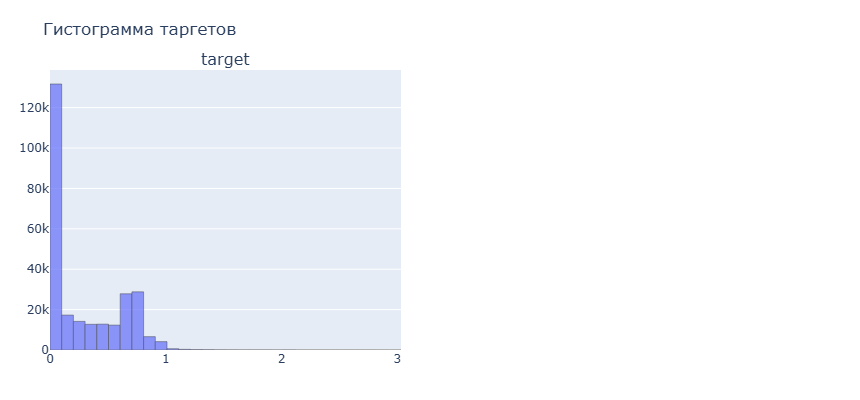

In [51]:
fig_hist = target_histogram(sample, [TARGET], log_scale=True, figsize=(10, 5), show=True)

In [32]:
Logger.current_logger().report_plotly(
    title="Распределение таргета",
    series="",
    figure=fig_hist,
)

█████████████████████████████████ 100% | 6.17/6.17 MB [02:07<00:00, 20.60s/MB]: 


2026-05-20 19:17:57,742 - clearml.storage - INFO - Uploading: 12.12MB from /home/jovyan/Clip/template/02_template_regression.ipynb


                                           0% | 0.00/12.12 MB [00:00<?, ?MB/s]: 

2026-05-20 19:17:57,854 - clearml.storage - INFO - Uploading: 12.12MB from /home/jovyan/Clip/template/02_template_regression.ipynb



███████████████████████████████ 100% | 12.12/12.12 MB [00:00<00:00, 74.20MB/s]: 


...

2026-05-20 19:22:00,298 - clearml.storage - INFO - Uploading: 6.15MB from /home/jovyan/Clip/template/02_template_regression.ipynb



█████████████████████████████████ 100% | 6.15/6.15 MB [00:00<00:00, 75.87MB/s]: 

2026-05-20 19:22:00,367 - clearml.storage - INFO - Uploading: 6.15MB from /home/jovyan/Clip/template/02_template_regression.ipynb



█████████████████████████████████ 100% | 6.15/6.15 MB [00:00<00:00, 78.90MB/s]: 

2026-05-20 19:22:00,379 - clearml.storage - ERROR - Exception encountered while uploading Failed uploading object /eservices-20158/eservices-20158_v1.982260653c1f4450ab0be5b5eec1e02e/artifacts/notebook/02_template_regression.ipynb to https://clearml-retail.run.fc.uralsibbank.ru (413): <html>
<head><title>413 Request Entity Too Large</title></head>
<body>
<center><h1>413 Request Entity Too Large</h1></center>
<hr><center>nginx</center>
</body>
</html>



In [45]:
def target_boxplot(
    df,
    target_cols,
    ncols=2,
    figsize=None,
    show=True,
):
    if isinstance(target_cols, str):
        target_cols = [target_cols]
    n = len(target_cols)
    nrows, ncols_grid = _target_grid(n, ncols)
    if figsize is None:
        figsize = (3 * ncols_grid, max(3.5, 3 * nrows))
    fig, axes = plt.subplots(nrows, ncols_grid, figsize=figsize, squeeze=False)
    for i, col in enumerate(target_cols):
        r, c = i // ncols, i % ncols
        x = df[col].dropna().astype(float)
        axes[r, c].boxplot(x, vert=False)
        axes[r, c].set_title(f"{col} (box)")
        axes[r, c].set_xlabel(col)
    for j in range(n, nrows * ncols_grid):
        axes.flat[j].set_visible(False)
    fig.suptitle("Boxplot таргет", y=1.02)
    plt.tight_layout()
    if show:
        plt.show()
    return fig

█████████████████████████████████ 100% | 6.19/6.19 MB [01:21<00:00, 13.18s/MB]: 


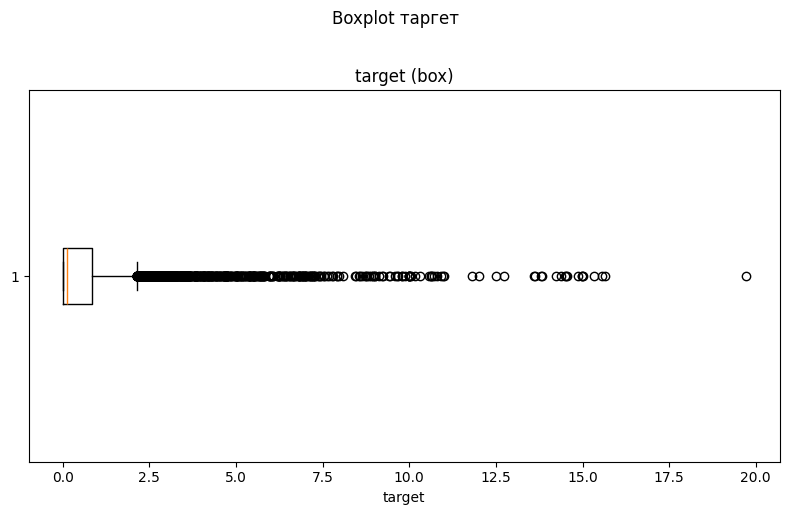

In [46]:
fig_box = target_boxplot(sample, [TARGET], ncols=1, figsize=(8, 5), show=True)

In [47]:
Logger.current_logger().report_matplotlib_figure(
    title="Boxplot таргет",
    series="",
    figure=fig_box,
    iteration=0,
)

2026-05-20 19:42:17,509 - clearml.storage - INFO - Uploading: 6.17MB from /home/jovyan/Clip/template/02_template_regression.ipynb


                                            0% | 0.00/6.17 MB [00:00<?, ?MB/s]: 

2026-05-20 19:42:17,581 - clearml.storage - INFO - Uploading: 6.17MB from /home/jovyan/Clip/template/02_template_regression.ipynb



█████████████████████████████████ 100% | 6.17/6.17 MB [00:00<00:00, 74.38MB/s]: 

2026-05-20 19:42:17,649 - clearml.storage - INFO - Uploading: 6.17MB from /home/jovyan/Clip/template/02_template_regression.ipynb


...

2026-05-20 19:48:20,489 - clearml.storage - INFO - Uploading: 6.18MB from /home/jovyan/Clip/template/02_template_regression.ipynb



█████████████████████████████████ 100% | 6.18/6.18 MB [00:00<00:00, 79.31MB/s]: 

2026-05-20 19:48:20,568 - clearml.storage - INFO - Uploading: 6.18MB from /home/jovyan/Clip/template/02_template_regression.ipynb



█████████████████████████████████ 100% | 6.18/6.18 MB [00:00<00:00, 71.17MB/s]: 

2026-05-20 19:48:20,579 - clearml.storage - ERROR - Exception encountered while uploading Failed uploading object /eservices-20158/eservices-20158_v1.982260653c1f4450ab0be5b5eec1e02e/artifacts/notebook/02_template_regression.ipynb to https://clearml-retail.run.fc.uralsibbank.ru (413): <html>
<head><title>413 Request Entity Too Large</title></head>
<body>
<center><h1>413 Request Entity Too Large</h1></center>
<hr><center>nginx</center>
</body>
</html>



### Сводка по таргетам: среднее, медиана, std, доля нулей
Таблица — общая и при необходимости по месяцам.

In [60]:
def target_summary(df, target_cols, by_month=False, date_col=None):
    """Таблица: count, mean, median, std, min, max, доля нулей. by_month=True — то же по месяцам."""
    df = df.copy()
    df[target_cols] = df[target_cols].astype(float)
    if by_month and date_col:   
        df["_month"] = df[date_col].dt.to_period("M")
        return df.groupby("_month")[target_cols].agg(
            ["count", "mean", "median", "std", "min", "max"]
        ).round(2)
    res = df[target_cols].agg(["count", "mean", "median", "std", "min", "max"]).T
    res["pct_zero"] = (df[target_cols] == 0).mean() * 100
    return res.round(2)

In [61]:
target_summary(sample, [TARGET])

,count,mean,median,std,min,max,pct_zero
target,270110.0,0.4,0.13,0.54,0.0,19.71,35.41


In [117]:
tbl = target_summary(sample, [TARGET], by_month=True, date_col='report_date')

In [118]:
tbl = tbl.T.droplevel(0).rename_axis("metric").reset_index()
tbl.columns.name = None
tbl.columns = [str(c) for c in tbl.columns]
tbl

,metric,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,...,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10
0,count,4229.00,22064.00,4210.00,4396.00,11331.00,9779.00,5470.00,22933.00,13430.00,...,12970.00,9212.00,16085.00,6391.00,8752.00,18694.00,10111.00,10594.00,9078.00,13083.00
1,mean,0.28,0.36,0.43,0.32,0.40,0.27,0.34,0.44,0.39,...,0.33,0.43,0.48,0.40,0.29,0.38,0.28,0.57,0.46,0.40
2,median,0.04,0.12,0.14,0.06,0.12,0.03,0.05,0.20,0.07,...,0.04,0.18,0.25,0.08,0.02,0.10,0.01,0.47,0.24,0.21
3,std,0.49,0.50,0.56,0.50,0.55,0.45,0.49,0.53,0.55,...,0.51,0.49,0.63,0.59,0.45,0.48,0.43,0.61,0.52,0.43
4,min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
5,max,13.82,14.98,9.11,9.66,15.00,10.70,7.91,9.44,9.80,...,14.86,4.74,19.71,14.53,8.96,10.06,5.19,14.39,6.42,2.74


In [115]:
Logger.current_logger().report_table(
    title="Размер выбороки/статистика по таргету",
    series=" ",
    table_plot=tbl
)

## 5. Собираем ВДР и фичи вместе

In [119]:
merged_df = sample.copy() 

In [120]:
%%time

MISSING_THRESHOLD = 0.8  # Доля пропусков не более чем

for feat_df, filename in tqdm.tqdm(zip(df_features_lst, filenames), total=len(df_features_lst)):
    duplicates = feat_df[feat_df.duplicated(subset=PRIMARY_KEY, keep=False)]
    diff_cols = (duplicates
                .groupby(PRIMARY_KEY)
                .nunique()
                .gt(1)
                .any(axis=0))
    res = diff_cols[diff_cols].index.tolist()
    feat_df = feat_df.drop(res, axis=1)
    feat_df = feat_df.drop_duplicates(subset=PRIMARY_KEY, keep='first')
    
    missing_df = preprocessing.analyze_missing_values(feat_df, missing_threshold=MISSING_THRESHOLD)
    if missing_df is not None and not missing_df.empty:
        missing_df.to_excel(f'{REPORTS_FOLDER}/{filename}_missing.xlsx')
        feat_df = preprocessing.remove_columns_by_missing(feat_df, missing_df, 0.8)
    
    merged_df = pd.merge(merged_df, feat_df, on=PRIMARY_KEY, how='left')

 21%|██▏       | 6/28 [00:11<00:39,  1.79s/it]

Нет колонок с пропусками > 80.0%


 25%|██▌       | 7/28 [00:11<00:31,  1.49s/it]

Нет колонок с пропусками > 80.0%


 32%|███▏      | 9/28 [00:16<00:39,  2.06s/it]

...

Нет колонок с пропусками > 80.0%


 93%|█████████▎| 26/28 [01:25<00:12,  6.01s/it]

Нет колонок с пропусками > 80.0%


100%|██████████| 28/28 [01:36<00:00,  3.45s/it]

CPU times: user 58.2 s, sys: 39.3 s, total: 1min 37s
Wall time: 1min 36s


In [121]:
# Чистим RAM
del df_features_lst
gc.collect()

53361

In [122]:
merged_df.info()
merged_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270200 entries, 0 to 270199
Columns: 5239 entries, client_did to transaction_cash_trans_avg_cnt_6m_to_total_6m
dtypes: category(39), datetime64[ns](2), float16(2706), float32(1889), float64(478), int16(13), int32(23), int64(2), int8(85), object(2)
memory usage: 4.3+ GB


(270200, 5239)

In [123]:
merged_df.drop(columns=TECH_COLS, inplace=True, errors="ignore")
merged_df = merged_df.drop_duplicates()

In [126]:
merged_df.drop(['current_debt_amt'], axis=1, inplace=True)

In [127]:
merged_df.shape

(270200, 5234)

In [128]:
display(merged_df.columns[:10])
all_features = merged_df.columns[4:] # Список всех доступных фичей

Index(['client_did', 'report_date', 'new_limit', 'target', 'year_month',
       'card_card_uid_aggcnt', 'card_card_uid_by_status_card_nm_aggcnt',
       'card_card_card_uid_by_status_card_nm_aggcnt_div_card_card_uid_aggcnt',
       'card_auto_reissue_flg_by_status_card_nm_aggmax',
       'card_ozc_flg_by_status_card_nm_aggmax'],
      dtype='object')

### Проверка

In [129]:
# Обязательно! Проверка что нет дублей по PRIMARY_KEY
assert merged_df[PRIMARY_KEY].drop_duplicates().shape[0] == merged_df[PRIMARY_KEY].shape[0]

In [130]:
# Если есть дубли - выведем столбцы с ними
duplicates = merged_df[merged_df.duplicated(subset=PRIMARY_KEY, keep=False)]
diff_cols = (duplicates
            .groupby(PRIMARY_KEY)
            .nunique()
            .gt(1)
            .any(axis=0))
res = diff_cols[diff_cols].index.tolist()
print(res)

[]


In [131]:
display(merged_df.shape)
display(merged_df.head(3))

(270200, 5234)

,client_did,report_date,new_limit,target,year_month,card_card_uid_aggcnt,card_card_uid_by_status_card_nm_aggcnt,card_card_card_uid_by_status_card_nm_aggcnt_div_card_card_uid_aggcnt,card_auto_reissue_flg_by_status_card_nm_aggmax,card_ozc_flg_by_status_card_nm_aggmax,...,transaction_cash_trans_sum_3m_to_total_3m,transaction_cash_trans_cnt_3m_to_total_6m,transaction_cash_trans_sum_3m_to_total_6m,transaction_cash_trans_cnt_6m_to_total_6m,transaction_cash_trans_sum_6m_to_total_6m,transaction_cash_trans_avg_cnt_3m_to_6m,transaction_cash_trans_avg_cnt_3m_to_total_3m,transaction_cash_trans_avg_cnt_3m_to_total_6m,transaction_cash_trans_avg_sum_6m_to_total_6m,transaction_cash_trans_avg_cnt_6m_to_total_6m
0,20127190033,2024-05-23,800000,0E-46,2024-05-01,1,1,1.0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20117845254,2023-12-21,90000,0.0883974444444444444444444444444444444444000000,2023-12-01,1,1,1.0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1171690331,2024-04-25,180000,0.0514150555555555555555555555555555555556000000,2024-04-01,6,3,0.5,1,1,...,0.052979,0.009804,0.029602,0.013069,0.033203,1.5,0.016388,0.019608,1.169922,0.013069


## 6. Отбор фичей (однофакторный анализ)


1. Убираем фичи с большой долей пропущенных значений
2. Убираем константные фичи
3. Убираем нестабильные фичи (`PSI > threshold`)
4. Разбиение на сегменты: TRAIN, TEST, OOT
5. Грубый отбор фичей (Оставляем ТОП-N фичей)

### 6.1 Убираем фичи с большой долей пропусков

In [132]:
MISSING_THRESHOLD = 0.8  # Доля пропусков не более чем

missing_df = preprocessing.analyze_missing_values(merged_df, missing_threshold=MISSING_THRESHOLD)
missing_df.to_excel(f'{REPORTS_FOLDER}/missing_percentage.xlsx')

In [133]:
merged_df = preprocessing.remove_columns_by_missing(merged_df, missing_df, 0.8)

In [134]:
merged_df.shape

(270200, 4294)

### 6.2 Убираем фичи с константными значениями (низкая дисперсия данных)

In [135]:
res = preprocessing.find_constant_features(merged_df, threshold=0.95, verbose=False)
res['constant']

['contract_dep_contract_uid_by_status_nm_arrest_aggmax',
 'dbo_dpasp_change_card_limit_reject_flg_m12',
 'dbo_dpasp_change_card_limit_reject_aggsum_m12',
 'dbo_dpasp_change_card_limit_reject_flg_m6',
 'dbo_dpasp_change_card_limit_reject_aggsum_m6',
 'dbo_dpasp_change_card_limit_reject_flg_m3',
 'dbo_dpasp_change_limit_plan_reject_flg_m3',
 'dbo_dpasp_change_card_limit_reject_aggsum_m3',
 'dbo_dpasp_change_limit_plan_reject_aggsum_m3',
 'dbo_dpasp_change_limit_plan_flg_m1',
 'dbo_client_authorize_aggsum_d1',
 'dbo_client_authorize_success_aggsum_d1',
 'dbo_client_authorize_fail_aggsum_d1',
 'dbo_client_authorize_mb_aggsum_d1',
 'dbo_client_authorize_mb_success_aggsum_d1',
 'dbo_client_authorize_mb_fail_aggsum_d1',
 'dbo_client_authorize_web_aggsum_d1',
 'dbo_client_authorize_web_success_aggsum_d1',
 'dbo_client_authorize_web_fail_aggsum_d1',
 'dbo_client_authorize_psw_aggsum_d1',
 'dbo_client_authorize_psw_success_aggsum_d1',
 'dbo_client_authorize_psw_fail_aggsum_d1',
 'dbo_client_auth

In [136]:
to_drop  = [col for col in merged_df.columns if merged_df[col].nunique() == 1 and col not in [TIME_COL, 'year_month']]
merged_df.drop(to_drop, axis = 1, inplace =True)

In [137]:
merged_df.shape

(270200, 4127)

### 6.3 Отбор по PSI

In [160]:
features = list(merged_df.drop(['report_date', 'client_did', 'new_limit', 'year_month'] +[TARGET], axis=1).columns)

In [158]:
features

['year_month',
 'card_card_uid_aggcnt',
 'card_card_uid_by_status_card_nm_aggcnt',
 'card_card_card_uid_by_status_card_nm_aggcnt_div_card_card_uid_aggcnt',
 'card_auto_reissue_flg_by_status_card_nm_aggmax',
 'card_ozc_flg_by_status_card_nm_aggmax',
 'card_is_digital_by_status_card_nm_aggmax',
 'card_izp_flg_by_status_card_nm_aggmax',
 'card_report_date_diff_card_close_dt_aggmin',
 'card_report_date_diff_card_close_dt_aggmax',
 'card_report_date_diff_card_close_dt_aggavg',
 'card_card_exp_dt_diff_report_date_aggmin',
 'card_card_exp_dt_diff_report_date_aggmax',
 'card_card_exp_dt_diff_report_date_aggavg',
 'card_report_date_diff_card_work_dt_aggmax',
 'card_report_date_diff_card_work_dt_aggavg',
 'card_work_diff_start_aggmin_d730',
 'card_work_diff_start_aggmax_d730',
 'card_work_diff_start_aggavg_d730',
 'card_work_diff_start_aggmin_d365',
 'card_work_diff_start_aggmax_d365',
 'card_work_diff_start_aggavg_d365',
 'card_sms_status_code_aggmax',
 'card_sms_end_diff_sms_start_aggmin_d730'

In [161]:
%%time
psi_result = preprocessing.calculate_feat_psi(merged_df[list(features) + ['year_month']], features, date_col='year_month')

CPU times: user 9min 19s, sys: 2.71 s, total: 9min 22s
Wall time: 9min 26s


In [162]:
psi_result.head(20)

,card_card_uid_aggcnt,card_card_uid_by_status_card_nm_aggcnt,card_card_card_uid_by_status_card_nm_aggcnt_div_card_card_uid_aggcnt,card_auto_reissue_flg_by_status_card_nm_aggmax,card_ozc_flg_by_status_card_nm_aggmax,card_is_digital_by_status_card_nm_aggmax,card_izp_flg_by_status_card_nm_aggmax,card_report_date_diff_card_close_dt_aggmin,card_report_date_diff_card_close_dt_aggmax,card_report_date_diff_card_close_dt_aggavg,...,transaction_cash_trans_sum_3m_to_total_3m,transaction_cash_trans_cnt_3m_to_total_6m,transaction_cash_trans_sum_3m_to_total_6m,transaction_cash_trans_cnt_6m_to_total_6m,transaction_cash_trans_sum_6m_to_total_6m,transaction_cash_trans_avg_cnt_3m_to_6m,transaction_cash_trans_avg_cnt_3m_to_total_3m,transaction_cash_trans_avg_cnt_3m_to_total_6m,transaction_cash_trans_avg_sum_6m_to_total_6m,transaction_cash_trans_avg_cnt_6m_to_total_6m
date,,,,,,,,,,,,,,,,,,,,,
2023-11-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2023-12-01,0.018549,0.005089,0.031935,0.012994,0.004991,0.0,0.0,0.038238,0.062005,0.023525,...,0.002301,0.001931,0.002858,0.002727,0.003075,0.002082,0.002283,0.001931,0.003666,0.002727
2024-01-01,0.147816,0.003468,0.167437,0.081702,0.013957,0.0,0.0,0.257431,0.203077,0.179668,...,0.005108,0.005806,0.005835,0.007404,0.011107,0.007650,0.004625,0.005806,0.018822,0.007404
2024-02-01,0.071620,0.001570,0.098990,0.156326,0.000760,0.0,0.0,0.143342,0.130491,0.099753,...,0.001674,0.004767,0.005578,0.008099,0.010100,0.004412,0.002120,0.004767,0.012943,0.008099
2024-03-01,0.090413,0.002243,0.114381,0.108668,0.002361,0.0,0.0,0.171492,0.138253,0.109496,...,0.008987,0.009562,0.009823,0.012607,0.014359,0.014342,0.009450,0.009562,0.019828,0.012607
2024-04-01,0.047356,0.000563,0.056841,0.095787,0.003495,0.0,0.0,0.132269,0.099054,0.068992,...,0.004809,0.007470,0.009524,0.015264,0.010876,0.021572,0.003976,0.007470,0.020085,0.015264
2024-05-01,0.140295,0.005360,0.167603,0.227591,0.001211,0.0,0.0,0.230100,0.194602,0.182043,...,0.018914,0.029325,0.028196,0.027873,0.027635,0.020117,0.018632,0.029325,0.024015,0.027873
2024-06-01,0.081135,0.000561,0.108970,0.102403,0.000149,0.0,0.0,0.231430,0.122877,0.121941,...,0.018013,0.024673,0.025124,0.029566,0.031496,0.039795,0.017907,0.024673,0.040388,0.029566
2024-07-01,0.128196,0.321084,0.127669,0.190910,0.002103,0.0,0.0,0.240755,0.165375,0.171323,...,0.056438,0.062139,0.061739,0.064122,0.067247,0.054244,0.055635,0.062139,0.056609,0.064122


In [163]:
# Фильтр 1: глобальное ограничение PSI на всей выборке
PSI_THRESHOLD = 0.15 # Убираем фичи, с PSI > PSI_THRESHOLD
# Фильтр 2: Ограничение тренда
# Если есть линейный тренд на рост PSI, то максимальный тренд PSI не более PSI_TREND
PSI_TREND = 0.05
# PSI_TREND = 0.1

In [164]:
to_del_all = []
for col in psi_result.columns:
    max_psi = psi_result[col].max()
    lrgs = linregress(range(len(psi_result[col])), psi_result[col])
    if ((lrgs.slope > 0) & (lrgs.pvalue < 0.05) & (psi_result[col].max() > PSI_TREND)) or psi_result[col].max() >= PSI_THRESHOLD:
        to_del_all.append(col)

In [165]:
psi_result[to_del_all].to_excel(f'{REPORTS_FOLDER}/psi_to_delete.xlsx')

In [166]:
len(to_del_all), merged_df.shape

(3339, (270200, 4127))

In [167]:
merged_df.drop(to_del_all, axis=1, inplace=True)

In [168]:
merged_df.shape

(270200, 788)

In [172]:
merged_df[TARGET] = merged_df[TARGET].astype(float)

In [174]:
merged_df = merged_df.dropna(subset=[TARGET])

In [175]:
merged_df.shape

(270110, 788)

### 6.4 Разбиение на сегменты: Train test split

Сегменты:
* `train` - Обучающая часть
* `test` - тестовая часть
* `oot` - в зависимости от типа валидации
* `other` - дубли, некорректные записи и тд

In [176]:
df = merged_df[merged_df['report_date'] < '2025.09.01']
oot = merged_df[merged_df['report_date'] >= '2025.09.01']
train = df[df['report_date'] < '2025.07.01']
test = df[df['report_date'] >= '2025.07.01']

In [177]:
train.shape, test.shape, oot.shape

((227244, 788), (20705, 788), (22161, 788))

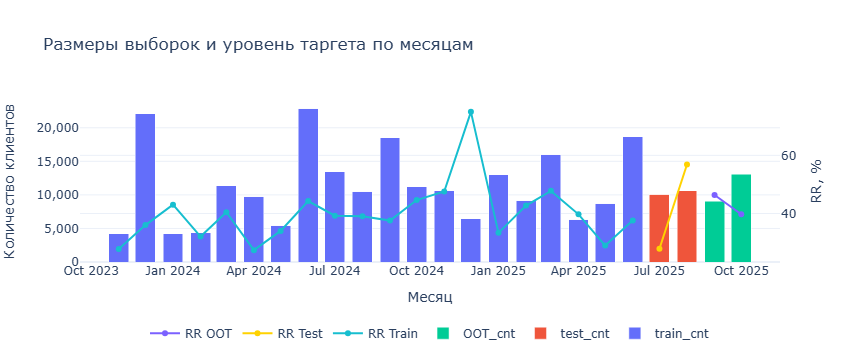

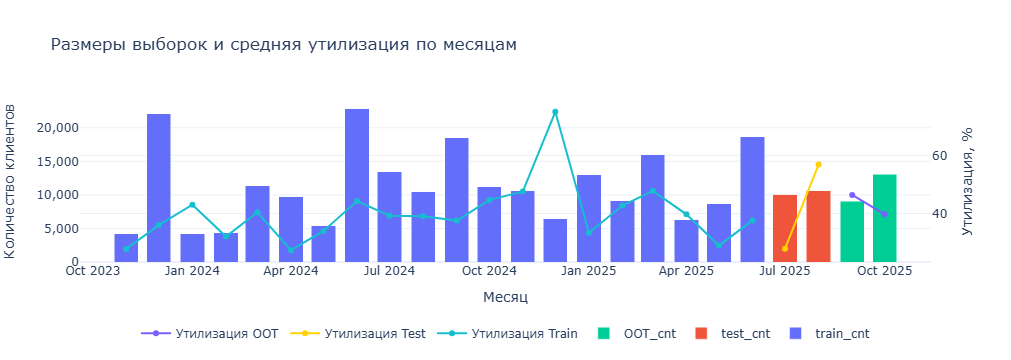

In [191]:
info_df, fig_df = report.counts_target_ratio(train, test, oot, TIME_COL, TARGET)
fig_df.update_layout(
    title="Размеры выборок и средняя утилизация по месяцам",
    yaxis2=dict(title="Утилизация, %", overlaying="y", side="right"),
)
for tr in fig_df.data:
    if tr.name and tr.name.startswith("RR "):
        tr.name = tr.name.replace("RR ", "Утилизация ")

info_df = info_df.rename(columns={
    "rr_train": "util_train",
    "rr_test": "util_test",
    "rr_oot": "util_oot",
})
fig_df

In [192]:
info_df

,month,train_cnt,test_cnt,oot_cnt,util_train,util_test,util_oot
0,2023-11-01,4229,---,---,27.84%,---,---
1,2023-12-01,22064,---,---,36.01%,---,---
2,2024-01-01,4210,---,---,43.03%,---,---
3,2024-02-01,4396,---,---,32.07%,---,---
4,2024-03-01,11331,---,---,40.42%,---,---
5,2024-04-01,9779,---,---,27.4%,---,---
6,2024-05-01,5470,---,---,34.03%,---,---
7,2024-06-01,22933,---,---,44.27%,---,---
8,2024-07-01,13430,---,---,39.24%,---,---
9,2024-08-01,10554,---,---,39.02%,---,---


In [196]:
Logger.current_logger().report_plotly(
    title="Размеры выборок и средняя утилизация по месяцам",
    series="",
    figure=fig_df)

In [195]:
info_df_to_log = info_df.copy()
info_df_to_log["month"] = pd.to_datetime(info_df_to_log["month"]).dt.strftime("%Y-%m-%d")
Logger.current_logger().report_table(
    title="Размеры выборок и средняя утилизация по месяцам",
    series="",
    table_plot=info_df_to_log
)
info_df

,month,train_cnt,test_cnt,oot_cnt,util_train,util_test,util_oot
0,2023-11-01,4229,---,---,27.84%,---,---
1,2023-12-01,22064,---,---,36.01%,---,---
2,2024-01-01,4210,---,---,43.03%,---,---
3,2024-02-01,4396,---,---,32.07%,---,---
4,2024-03-01,11331,---,---,40.42%,---,---
5,2024-04-01,9779,---,---,27.4%,---,---
6,2024-05-01,5470,---,---,34.03%,---,---
7,2024-06-01,22933,---,---,44.27%,---,---
8,2024-07-01,13430,---,---,39.24%,---,---
9,2024-08-01,10554,---,---,39.02%,---,---


In [179]:
# Проверка на потерянные строки 
assert train[PRIMARY_KEY].shape[0] +\
        test[PRIMARY_KEY].shape[0] +\
         oot[PRIMARY_KEY].shape[0] == sample.dropna(subset=[TARGET]).shape[0]

## 7. Предварительный отбор фичей

In [183]:
# Доработать
categorical_features = list(merged_df
                            .drop(columns=PRIMARY_KEY+['year_month',TARGET])
                            .select_dtypes(['category', 'object'])
                            .columns)
numerical_features = list(merged_df
                          .drop(columns=categorical_features + PRIMARY_KEY + ['year_month',TARGET])
                          .columns)

print(f'Categorical: {len(categorical_features)}')
print(f'Numerical: {len(numerical_features)}')

Categorical: 9
Numerical: 775


In [184]:
features = categorical_features + numerical_features

In [185]:
features

['client_cl_category_nm',
 'client_izp_flg',
 'client_call_consent_flg',
 'client_sms_consent_flg',
 'client_messenger_consent_flg',
 'client_email_consent_flg',
 'application_employer_ownership_type',
 'dbo_client_info_status_profile',
 'dbo_client_info_push_flg',
 'new_limit',
 'card_ozc_flg_by_status_card_nm_aggmax',
 'card_is_digital_by_status_card_nm_aggmax',
 'card_izp_flg_by_status_card_nm_aggmax',
 'card_sms_end_diff_sms_start_aggmin_d730',
 'card_sms_end_diff_sms_start_aggmin_d365',
 'card_sms_end_diff_sms_start_aggmin_d180',
 'card_sms_end_diff_sms_start_aggmin_d90',
 'card_sms_end_diff_sms_start_aggmax_d90',
 'card_bm_off_diff_bm_on_aggmin_d730',
 'card_bm_off_diff_bm_on_aggmin_d365',
 'card_bm_off_diff_bm_on_aggmin_d180',
 'card_bm_off_diff_bm_on_aggmin_d90',
 'card_bm_off_diff_bm_on_aggmax_d90',
 'card_spec_offer_code_aggmax_d90',
 'dbo_client_authorize_days_from_last_mb_success_auth',
 'dbo_client_authorize_web_aggsum_m6',
 'dbo_client_authorize_web_aggsum_m3',
 'dbo_clie

In [197]:
def select_by_importance(data, target_col, eval_data, max_features=None, importance_threshold=None, random_state=42):
    """
    Важность из LGBMRegressor. Возвращает (selected, imp, model) — model для evaluate_model.
    """
    X = data.drop(columns=[target_col])
    y = data[target_col]
    eval_set = [(eval_data.drop(columns=[target_col]), eval_data[target_col])]
    X_ = X.select_dtypes(include=[np.number]).copy()
    eval_align = [(X_val[X_.columns], y_val) for X_val, y_val in eval_set]
    m = lgb.LGBMRegressor(random_state=random_state, n_estimators=100, max_depth=4, verbosity=-1)
    m.fit(X_, y, eval_set=eval_align)
    imp = pd.Series(m.feature_importances_, index=X_.columns).sort_values(ascending=False)
    selected = imp[imp >= importance_threshold].index.tolist() if importance_threshold is not None else imp.index.tolist()
    if max_features is not None:
        selected = imp.head(max_features).index.tolist()
    return selected, imp, m


def evaluate_model(model, train_df, test_df, oot_df, target_col):
    """
    Сводка по модели: Train / Test / OOT. Возвращает DataFrame с колонками:
    Target, AVG target, AVG pred, Dataset, MAPE, MAE, MAE 95%, RMSE, Non Zero.
    MAE 95% — MAE по 95% данных без 5% наибольших значений таргета y (выбросы по y).
    """
    feat = getattr(model, "feature_name_", None) or getattr(model, "feature_names_in_", None)
    if feat is None:
        feat = [c for c in train_df.columns if c != target_col]
    rows = []
    for name, df in [("Train", train_df), ("Test", test_df), ("OOT", oot_df)]:
        X = df[feat] if all(c in df.columns for c in feat) else df.drop(columns=[target_col])
        y = df[target_col].values
        pred = model.predict(X)
        nz = (y != 0)
        mape = np.mean(np.abs((y - pred)[nz]) / y[nz]) if nz.sum() > 0 else np.nan
        mae = np.mean(np.abs(y - pred))
        thresh_y = np.percentile(y, 95)
        mask = y <= thresh_y
        mae_95 = np.mean(np.abs(y[mask] - pred[mask])) if mask.sum() > 0 else np.nan
        rmse = np.sqrt(np.mean((y - pred) ** 2))
        rows.append({
            "Target": target_col,
            "AVG target": y.mean(),
            "AVG pred": pred.mean(),
            "Dataset": name,
            "MAPE": mape,
            "MAE": mae,
            "MAE 95%": mae_95,
            "RMSE": rmse,
            "Non Zero": int(nz.sum()),
        })
    return pd.DataFrame(rows)

In [198]:
def metric_vs_n_features(data, target_col, eval_data, imp, step=30, metric="rmse", random_state=42, threshold=0.005):
    """
    Перебор числа признаков по важности: от 20 с шагом step до n_all. imp — результат select_by_importance.
    threshold: порог — берётся наименьшее n, при котором метрика <= минимум * (1 + threshold). Например 0.005 = 0.5%.
    Если None — просто argmin. Возвращает (report_df, best_n, selected, model).
    """
    MIN_FEATURES = 20
    n_all = len(imp)
    start = min(MIN_FEATURES, n_all)
    n_features_list = list(range(start, n_all + 1, step))
    if n_all not in n_features_list:
        n_features_list.append(n_all)
    n_features_list = sorted(set(n_features_list))

    X_ev = eval_data[imp.index.tolist()]
    y_ev = eval_data[target_col].values
    fn = mean_squared_error if metric == "rmse" else mean_absolute_error

    rows = []
    for n in n_features_list:
        cols = imp.head(n).index.tolist()
        X_tr = data[cols]
        y_tr = data[target_col]
        m = lgb.LGBMRegressor(random_state=random_state, n_estimators=100, max_depth=4, verbosity=-1)
        m.fit(X_tr, y_tr, eval_set=[(X_ev[cols], y_ev)])
        pred = m.predict(X_ev[cols])
        val = np.sqrt(fn(y_ev, pred)) if metric == "rmse" else fn(y_ev, pred)
        rows.append({"n_features": n, "metric_value": val})

    report_df = pd.DataFrame(rows)
    best_metric = report_df["metric_value"].min()
    if threshold is not None:
        metric_limit = best_metric * (1 + threshold)
        candidates = report_df[report_df["metric_value"] <= metric_limit].sort_values("n_features")
        best_n = int(candidates.iloc[0]["n_features"]) if len(candidates) > 0 else int(report_df.loc[report_df["metric_value"].idxmin(), "n_features"])
    else:
        best_n = int(report_df.loc[report_df["metric_value"].idxmin(), "n_features"])
    selected = imp.head(best_n).index.tolist()
    model = lgb.LGBMRegressor(random_state=random_state, n_estimators=100, max_depth=4, verbosity=-1)
    model.fit(data[selected], data[target_col], eval_set=[(eval_data[selected], eval_data[target_col])])

    plt.figure(figsize=(8, 4))
    plt.plot(report_df["n_features"], report_df["metric_value"], marker="o")
    plt.axvline(best_n, color="gray", linestyle="--", label=f"best n={best_n}")
    plt.xlabel("Число признаков")
    plt.ylabel(metric.upper())
    plt.title(f"Метрика на eval от n для {target_col}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return report_df, best_n, selected, model

In [199]:
def tune_hyperparams(data, target_col, eval_data, max_evals=30, metric="rmse", random_state=42):
    """
    Подбор гиперпараметров LGBM через Hyperopt (TPE). 
    Возвращает (best_model, best_params).
    """
    X = data.drop(columns=[target_col])
    y = data[target_col]
    X_ev = eval_data.drop(columns=[target_col])
    y_ev = eval_data[target_col].values
    fn = mean_squared_error if metric == "rmse" else mean_absolute_error

    space = {
        "n_estimators": hp.quniform("n_estimators", 50, 300, 25),
        "max_depth": hp.quniform("max_depth", 3, 10, 1),
        "learning_rate": hp.loguniform("learning_rate", np.log(0.02), np.log(0.3)),
        "num_leaves": hp.quniform("num_leaves", 15, 127, 10),
        "min_child_samples": hp.quniform("min_child_samples", 5, 50, 5),
    }

    def objective(params):
        p = {
            "n_estimators": int(params["n_estimators"]),
            "max_depth": int(params["max_depth"]),
            "learning_rate": params["learning_rate"],
            "num_leaves": int(params["num_leaves"]),
            "min_child_samples": int(params["min_child_samples"]),
        }
        m = lgb.LGBMRegressor(random_state=random_state, verbosity=-1, **p)
        m.fit(X, y, eval_set=[(X_ev, y_ev)])
        pred = m.predict(X_ev)
        score = np.sqrt(fn(y_ev, pred)) if metric == "rmse" else fn(y_ev, pred)
        return {"loss": score, "status": STATUS_OK}

    trials = Trials()
    best = fmin(
        objective, space, algo=tpe.suggest, max_evals=max_evals, trials=trials,
        rstate=np.random.default_rng(random_state),
    )
    best_params = {
        "n_estimators": int(best["n_estimators"]),
        "max_depth": int(best["max_depth"]),
        "learning_rate": best["learning_rate"],
        "num_leaves": int(best["num_leaves"]),
        "min_child_samples": int(best["min_child_samples"]),
    }
    best_model = lgb.LGBMRegressor(random_state=random_state, verbosity=-1, **best_params)
    best_model.fit(X, y, eval_set=[(X_ev, y_ev)])
    return best_model, best_params

/opt/conda/lib/python3.11/site-packages/clearml/utilities/plotlympl/mplexporter/exporter.py:101: UserWarning:

Blended transforms not yet supported. Zoom behavior may not work as expected.



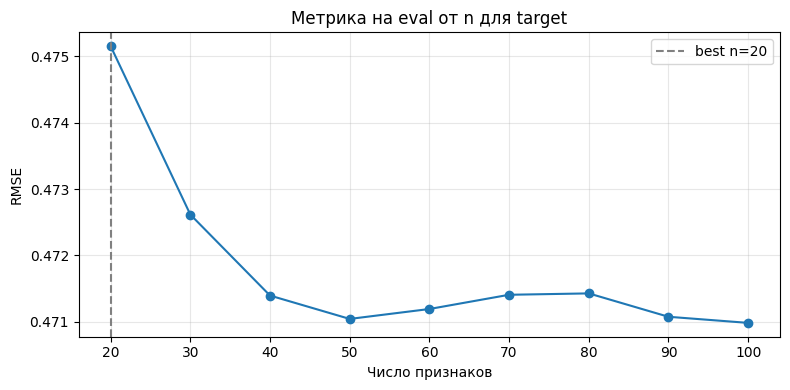

  0%|          | 0/30 [00:00<?, ?trial/s, best loss=?]

2026-05-21 23:21 INFO build_posterior_wrapper took 0.001059 seconds
2026-05-21 23:21 INFO TPE using 0 trials


  3%|▎         | 1/30 [00:01<00:51,  1.78s/trial, best loss: 0.47462851354624697]

2026-05-21 23:21 INFO build_posterior_wrapper took 0.001251 seconds
2026-05-21 23:21 INFO TPE using 1/1 trials with best loss 0.474629


  7%|▋         | 2/30 [00:02<00:31,  1.14s/trial, best loss: 0.47462851354624697]

...

 93%|█████████▎| 28/30 [00:39<00:03,  1.76s/trial, best loss: 0.4716256902139057]

2026-05-21 23:22 INFO build_posterior_wrapper took 0.001595 seconds
2026-05-21 23:22 INFO TPE using 28/28 trials with best loss 0.471626


 97%|█████████▋| 29/30 [00:42<00:02,  2.15s/trial, best loss: 0.4715436425344148]

2026-05-21 23:22 INFO build_posterior_wrapper took 0.001474 seconds
2026-05-21 23:22 INFO TPE using 29/29 trials with best loss 0.471544


100%|██████████| 30/30 [00:45<00:00,  1.52s/trial, best loss: 0.4715436425344148]
CPU times: user 15min 5s, sys: 12.2 s, total: 15min 17s
Wall time: 1min 11s


In [202]:
%%time
PRESELECTION_TOP_N = 100  # Количество предварительно отобранных фичей

results = {}

for target in [TARGET]:
    # Предварительный отбор фичей
    selected, imp, _ = select_by_importance(train[features + [target]], target, 
                                                eval_data=test[features + [target]], max_features=PRESELECTION_TOP_N)
    # Подбор оптимального количества фичей
    report_n, best_n, selected, model = metric_vs_n_features(train[selected + [target]], target, 
                                                             eval_data=test[selected + [target]], imp=imp[selected], step=10, threshold=0.01)
    # Подбор гиперпараметров
    best_model, best_params = tune_hyperparams(train[selected + [target]], target, test[selected + [target]], max_evals=30)
    report = evaluate_model(best_model, train[selected + [target]], test[selected + [target]], oot[selected + [target]], target)

    results[target] = {
        "selected": selected,
        "model": best_model,
        "evaluate_report": report,
        "best_n": best_n,
        "best_params": best_params,
        "metric_vs_n": report_n,
    }

# Сводная таблица по всем таргетам (Train/Test/OOT)
reports_all = pd.concat([results[t]["evaluate_report"] for t in [TARGET]], ignore_index=True)

In [203]:
reports_all

,Target,AVG target,AVG pred,Dataset,MAPE,MAE,MAE 95%,RMSE,Non Zero
0,target,0.399918,0.399918,Train,308.499399,0.293657,0.260795,0.435659,146303
1,target,0.427100,0.423303,Test,59.172449,0.320588,0.285289,0.471544,13199
2,target,0.424555,0.427772,OOT,483.059600,0.315732,0.292717,0.409550,14943


In [206]:
from sklearn.metrics import r2_score

In [221]:
def check_working_model(train, train_pred):
    y = train["target"].astype(float).values
    y_const = np.full_like(y, y.mean())
    print("MAE const:", mean_absolute_error(y, y_const))
    print("R2 model :", r2_score(y, train_pred))

In [222]:
check_working_model(train, results['target']['model'].predict(train[results['target']['selected']]))

MAE const: 0.4280471970526455
R2 model : 0.34774174901134103


In [224]:
print("R2 test :", r2_score(test["target"].astype(float).values, 
                            results['target']['model'].predict(test[results['target']['selected']])))

R2 test : 0.27088218718425405


In [225]:
print("R2 test :", r2_score(oot["target"].astype(float).values, 
                            results['target']['model'].predict(oot[results['target']['selected']])))

R2 test : 0.24010261331467708


In [223]:
results['target']

{'selected': ['new_limit',
  'contract_agg_monthly_cred_pil_debt_share_aggavg_12m',
  'contract_agg_monthly_cred_pil_debt_share_aggmax_6m',
  'contract_agg_monthly_dep_card_debit_client_turn_aggavg_1m',
  'contract_agg_monthly_dep_total_interest_rate_aggavg_24m',
  'crds_cci_agreewithpresale_aggavg_d180',
  'transaction_supermarkets_trans_avg_sum_12m',
  'contract_cred_current_debt_amt_by_status_nm_wrk_by_product_category_nm_ptb_pil_aggsum',
  'contract_delinquency_interval_total_overdue_principal_sum_aggmax',
  'card_sms_end_diff_sms_start_aggmin_d730',
  'half_posting_mpc_trx_out_sum_aggavg_m6',
  'contract_agg_monthly_dep_card_debit_turn_share_1m',
  'dbo_dpasp_appl_total_cred_reject_cnt_aggsum_m3',
  'client_contact_contact_by_category_home_aggcnt',
  'card_is_digital_by_status_card_nm_aggmax',
  'crds_cci_instant_aggsum_d180',
  'crds_cci_agreewithpresale_aggsum_d720',
  'dbo_dpasp_days_from_last_trans_self',
  'crds_cci_max_limit_presale_aggmin_d720',
  'dbo_dpasp_trans_sbp_amt_a

## 10. Сохранение артефактов

In [ ]:
s3_secret = (await Secret.load("s3-retail")).get()

In [ ]:
ACCESS_KEY = s3_secret["access_key"]
SECRET_KEY = s3_secret["secret_key"]

In [ ]:
from minio import Minio

client = Minio(
    endpoint="10.167.8.142:9000",
    access_key=ACCESS_KEY,
    secret_key=SECRET_KEY,
    secure=False
)    

In [ ]:
def create_df(df, target, pred_col, y_pred, segment_name):
    result_df = df[PRIMARY_KEY+[target]].copy()
    result_df[pred_col] = y_pred
    result_df['segment'] = segment_name

    return result_df

all_psi = []
description_dfs = []
for target in TARGETS:
    os.makedirs(f"{PATH_MODELS_DATA}/{target}/", exist_ok=True)
    best_features = results[target]['selected']
    train_df = create_df(train, target, f'{target}_pred', results[target]['model'].predict(train[best_features]), 'train')
    test_df = create_df(test, target, f'{target}_pred', results[target]['model'].predict(test[best_features]), 'test')
    oot_df = create_df(oot, target, f'{target}_pred', results[target]['model'].predict(oot[best_features]), 'oot')
    
    scored_df = pd.concat([train_df, test_df, oot_df], ignore_index=True)
    
    # сохраняем train, test, oot выборки после отбора фичей и проскоренную выборку
    train[PRIMARY_KEY + best_features + [target]].to_parquet(f"{PATH_MODELS_DATA}/{target}/sample_train.parquet")
    test[PRIMARY_KEY + best_features + [target]].to_parquet(f"{PATH_MODELS_DATA}/{target}/sample_test.parquet")
    oot[PRIMARY_KEY + best_features + [target]].to_parquet(f"{PATH_MODELS_DATA}/{target}/sample_oot.parquet")
    scored_df.to_parquet(f"{PATH_MODELS_DATA}/{target}/scored_df.parquet")

    psi_scores = preprocessing.calculate_feat_psi(scored_df[[f'{target}_pred', 'report_date']], [f'{target}_pred'], date_col='report_date')
    psi_scores = psi_scores.rename(columns={f'{target}_pred':'PSI'})
    psi_scores['target'] = target
    all_psi.append(psi_scores)

    psi_result[best_features].T.to_excel(f'{REPORTS_FOLDER}/psi_top20_{target}.xlsx')
    
    features_sql = ','.join(f"'{f}'" for f in best_features)

    engine_sb_dirkaim = oracle.create_engine_cdw(USERNAME_SB_DIRKAIM, PASSWORD_SB_DIRKAIM)
    with engine_sb_dirkaim.connect() as conn:
        description_df =  pd.read_sql(f"""select * from SB_DIRKAIM.FEATURE_REGISTRY where f_name in ({features_sql})""", conn)
    description_df = description_df[['f_name', 'f_desc', 'proc']]
    description_df['target'] = target
    description_dfs.append(description_df)

    client.fput_object('retail', 
                       f'models/eservices-{TASK_NUM}/{SUBTASK}/{target}/train.paruqet',
                       f'{PATH_MODELS_DATA}/{target}/sample_train.parquet')
    client.fput_object('retail', 
                       f'models/eservices-{TASK_NUM}/{SUBTASK}/{target}/test.paruqet',
                       f'{PATH_MODELS_DATA}/{target}/sample_test.parquet')
    client.fput_object('retail', 
                       f'models/eservices-{TASK_NUM}/{SUBTASK}/{target}/oot.paruqet', 
                       f'{PATH_MODELS_DATA}/{target}/sample_oot.parquet')
    client.fput_object('retail', 
                       f'models/eservices-{TASK_NUM}/{SUBTASK}/{target}/scored_df.paruqet', 
                       f'{PATH_MODELS_DATA}/{target}/scored_df.parquet')

In [ ]:
psi_pred = pd.concat(all_psi, ignore_index=True)
descriptions = pd.concat(description_dfs, ignore_index=True)

## 12. Публикация модели в Model_Registry

In [ ]:
# Креды для подключения S3
s3_kwargs = (await Secret.load("s3-retail")).get()
# Пароль для работы с SB_DIRKAIM (!)
cdw_pass = (await Secret.load("pass-sb-dirkaim")).get() 


from model_repository import ModelRepository
from model_repository.dao import OracleDAO
from model_repository.storage import MinioClient

engine = oracle.create_engine_cdw(
    username="KOVALENKOVDY[SB_DIRKAIM]", password=cdw_pass
)
dao = OracleDAO(engine)
storage = MinioClient(**s3_kwargs)

# Инициализируем класс ModelRepository
repo = ModelRepository(storage=storage, dao=dao)

In [ ]:
TARGETS_CAT = [
    'supermarkets_v2_cnt_1m',
    'supermarkets_v2_sum_1m'
]

In [ ]:
import pickle
from model_repository import RegisterRequest

In [ ]:
monthYear = datetime.datetime.now().strftime('%m%y')

for target, prod in zip(TARGETS, TARGETS_CAT):
    MODEL_NAME = f"{ML_TYPE}_{prod}_{monthYear}_{SUBTASK}"
    output_file = f"{PATH_MODELS_DATA}/{target}/{MODEL_NAME}.pkl"
    with open(output_file, 'wb') as file: 
        pickle.dump(results[target]['model'], file) 
    print(MODEL_NAME)
    req = RegisterRequest(
        model_name=MODEL_NAME,
        model_type="lightgbm",  # "catboost" | "lightgbm" | "sklearn" | "other"
        artifact_format="pickle",
        uri=f"retail/models/eservices-{TASK_NUM}/{SUBTASK}/{MODEL_NAME}.pkl",
        created_by=AUTHOR,
        description="Модель предсказания суммы/количества трат в MCC категории в течение 30 дней", # Описание целевой переменной
        scoring_flg=1,  # Флаг что модель на активном скоринге
        monitoring_flg=0,  # Флаг что модель на мониторинге
        is_online=0,  # Флаг онлайн модели
        model_obj=results[target]['model'],  # авто-сериализуем, авто-извлечём важности
    )
    # Регистрируем модель
    meta = repo.register(req)
    print(meta)
    # Проверка что модель зарегистрирована
    assert repo.exists(MODEL_NAME)

In [ ]:
reports_all

In [ ]:
psi_pred

In [ ]:
descriptions

In [ ]:
with pd.ExcelWriter(f"report_{MCC_CAT}.xlsx", engine="openpyxl") as writer:
    reports_all.to_excel(writer, sheet_name="Лист1", index=False)
    psi_pred.to_excel(writer, sheet_name="Лист2", index=False)
    descriptions.to_excel(writer, sheet_name="Лист3", index=False)

In [ ]:
for i in descriptions['f_name'].unique():
    print(f'{i},')

In [ ]:
for i in descriptions['proc'].unique():
    print(f'LEFT JOIN {i} t1 on a.client_did = t1.client_did ')

In [ ]:
with engine_cdw.connect() as conn:
    df_to_score = pd.read_sql(f"""select * from ema_supermarkets_mcc""", conn)

In [ ]:
df_to_score

In [ ]:
df_out = []
for target, prod in zip(TARGETS, TARGETS_CAT):
    best_features = results[target]['selected']
    preds = results[target]['model'].predict(df_to_score[best_features])
    out_scores = df_to_score[['client_did', 'report_date']].copy()
    out_scores['score'] = preds
    out_scores['model_name'] = f"{ML_TYPE}_{prod}_{monthYear}_{SUBTASK}"
    df_out.append(out_scores)

In [ ]:
res_scored = pd.concat(df_out, axis=0, ignore_index=True)

In [ ]:
res_scored.to_parquet(f'scoring/{MCC_CAT}.parquet')